## DX799S O1 Data Science Capstone (Summer 1 2025): ACTIVITY 9.2 ##

Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone Two, create a Jupyter Notebook (similar to in Module B, Semester Two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data using the methods you have learned about in this course and in this program and draw interesting conclusions.  

For this week, include ideas such as gradient boost, learning rate, number of estimators, tree depth, and regularization. This homework should be submitted for peer review in the assignment titled 9.3 Peer Review: Week 9 Jupyter Notebook. Complete and submit your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In Week 12, you will compile your findings from your Jupyter Notebook homework into your Milestone Two assignment for grading. For full instructions and the rubric for Milestone Two, refer to the following link. 

The following dataset, "Video Review", is a collection of information that was created based on reviewable video evidence that outlines the events that resulted in a concussion during punt players in the NFL 2016-2017 season. The target, Primary_Impact_Type, outlines if the concussion occurred from the impact of Helmet-to-Helmet, Helmet-to-Body, or Helmet-to-Ground.

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score

In [8]:
#Video Review Dataset 

df_video_review = pd.read_csv("video_review.csv")

label_encoder_video = LabelEncoder()

print("Object columns before encoding (Video Review):")
print(df_video_review.select_dtypes(include=['object']).columns)

for col in df_video_review.select_dtypes(include=['object']).columns:
    df_video_review[col] = label_encoder_video.fit_transform(df_video_review[col].astype(str))

target_video_review = 'Primary_Impact_Type'
X_video_review = df_video_review.drop(columns=[target_video_review])
y_video_review = df_video_review[target_video_review]

X_train_video_review, X_test_video_review, y_train_video_review, y_test_video_review = train_test_split(
    X_video_review, y_video_review, test_size=0.2, random_state=42
)

scaler_video_review = StandardScaler()
X_train_video_review = scaler_video_review.fit_transform(X_train_video_review)


Object columns before encoding (Video Review):
Index(['Player_Activity_Derived', 'Turnover_Related', 'Primary_Impact_Type',
       'Primary_Partner_GSISID', 'Primary_Partner_Activity_Derived',
       'Friendly_Fire'],
      dtype='object')


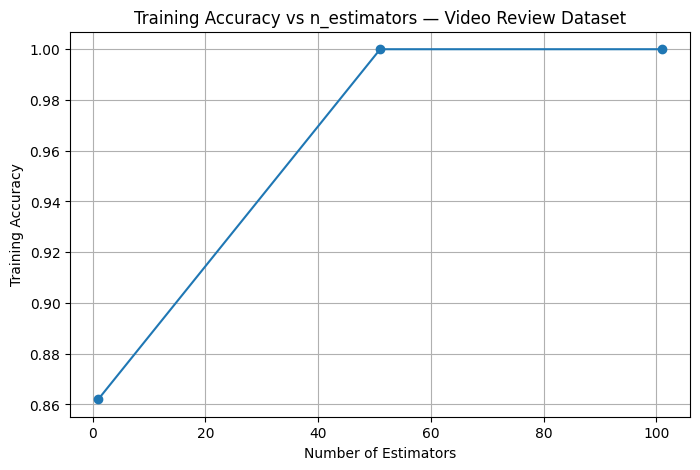

In [9]:
# Video Review Validation Curve 

train_scores_video_review = []
estimators_range_video_review = range(1, 150, 50)

for n in estimators_range_video_review:
    model_video_review = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    model_video_review.fit(X_train_video_review, y_train_video_review)
    train_scores_video_review.append(accuracy_score(y_train_video_review, model_video_review.predict(X_train_video_review)))

plt.figure(figsize=(8, 5))
plt.plot(estimators_range_video_review, train_scores_video_review, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs n_estimators — Video Review Dataset")
plt.grid(True)
plt.show()




In [5]:
#Video Review Dataset Hyperparameter Tuning

param_grid_video_review = {
    'n_estimators': [20, 40, 60, 80],
    'learning_rate': [0.01, 0.05],
    'max_depth': [2, 3],
    'subsample': [0.6, 0.8],
    'max_features': ['sqrt', 'log2']
}

grid_search_video_review = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_video_review,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_video_review.fit(X_train_video_review, y_train_video_review)

print("Best Parameters — Video Review Dataset:", grid_search_video_review.best_params_)
print("Best CV Score — Video Review Dataset:", grid_search_video_review.best_score_)



Fitting 5 folds for each of 64 candidates, totalling 320 fits


/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters — Video Review Dataset: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 80, 'subsample': 0.6}
Best CV Score — Video Review Dataset: 0.5533333333333333


In [12]:
#Video Review Cross Validation

best_model_video_review = grid_search_video_review.best_estimator_

cv_scores_video_review = cross_val_score(
    best_model_video_review,
    X_train_video_review,
    y_train_video_review,
    cv=5,
    scoring='accuracy'
)

print("Cross-Validation Accuracy Scores — Video Review Dataset:", cv_scores_video_review)
print("Mean CV Accuracy — Video Review Dataset:", np.mean(cv_scores_video_review))



/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross-Validation Accuracy Scores — Video Review Dataset: [0.5        0.66666667 0.5        0.5        0.6       ]
Mean CV Accuracy — Video Review Dataset: 0.5533333333333333


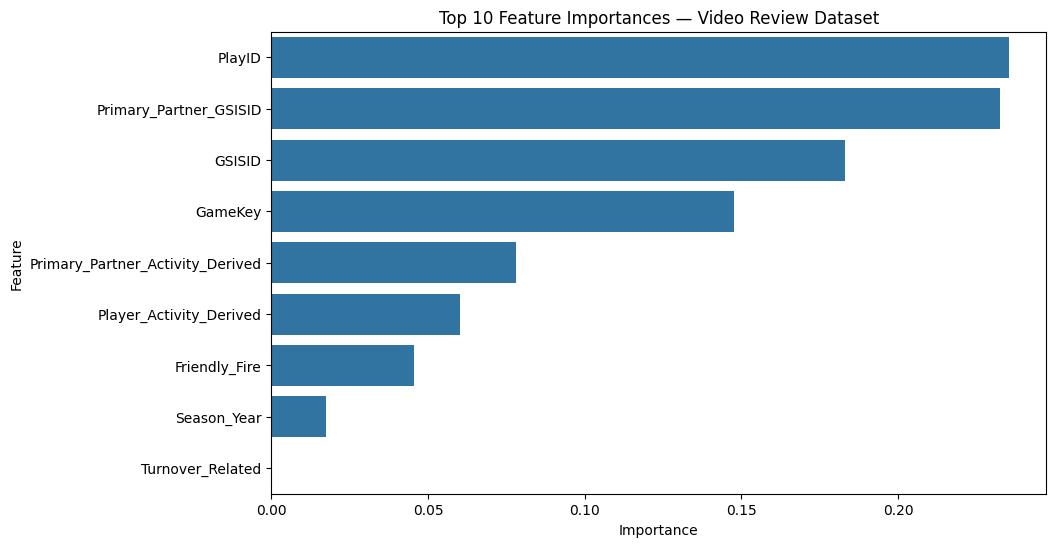

In [13]:
#Video Review Feature Importance Visualization
importances_video_review = best_model_video_review.feature_importances_
feature_names_video_review = df_video_review.drop(columns=[target_video_review]).columns

feat_imp_df_video_review = pd.DataFrame({
    'Feature': feature_names_video_review,
    'Importance': importances_video_review
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df_video_review.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances — Video Review Dataset")
plt.show()


The next dataset, Injury Record, looks to determine the relationship between the playing surface and the injury and performance of NFL athletes. The Injury Record dataset accounts for 105 lower-limbs injuries that occurred over two seasons during the regular NFL season and provides information on the surface the game occurred on and the number of days the player missed due to injury (or how severe it was). The target in this case is surface which lists the type of surface (synethic or natural) the field was when the injury occurred.

In [14]:
#Injury Record Dataset

injury_df = pd.read_csv("InjuryRecord.csv")

injury_label_encoder = LabelEncoder()

print("Object columns before encoding:")
print(injury_df.select_dtypes(include=['object']).columns)

for col in injury_df.select_dtypes(include=['object']).columns:
    injury_df[col] = injury_label_encoder.fit_transform(injury_df[col].astype(str))

injury_target_column = 'Surface'
X_injury = injury_df.drop(columns=[injury_target_column])
y_injury = injury_df[injury_target_column]

X_injury_train, X_injury_test, y_injury_train, y_injury_test = train_test_split(
    X_injury, y_injury, test_size=0.2, random_state=42
)

injury_scaler = StandardScaler()
X_injury_train_scaled = injury_scaler.fit_transform(X_injury_train)

Object columns before encoding:
Index(['GameID', 'PlayKey', 'BodyPart', 'Surface'], dtype='object')


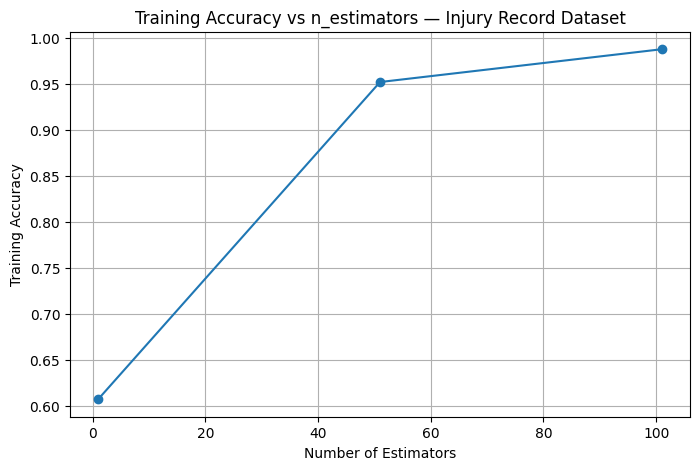

In [15]:
#Injury Record Validation Curve

train_scores_injury = []
estimators_range_injury = range(1, 150, 50)

for n in estimators_range_injury:
    model_injury = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    model_injury.fit(X_injury_train_scaled, y_injury_train)
    train_scores_injury.append(accuracy_score(y_injury_train, model_injury.predict(X_injury_train_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(estimators_range_injury, train_scores_injury, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs n_estimators — Injury Record Dataset")
plt.grid(True)
plt.show()


In [16]:
#Injury Record Hyperparameter Tuning

param_grid_injury = {
    'n_estimators': [40, 50, 60, 80],
    'learning_rate': [0.01, 0.05],
    'max_depth': [2, 3],
    'subsample': [0.6, 0.8],
    'max_features': ['sqrt', 'log2']
}

grid_search_injury = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_injury,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_injury.fit(X_injury_train_scaled, y_injury_train)

print("Best Parameters — Injury Record Dataset:", grid_search_injury.best_params_)
print("Best CV Score — Injury Record Dataset:", grid_search_injury.best_score_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters — Injury Record Dataset: {'learning_rate': 0.01, 'max_depth': 2, 'max_features': 'sqrt', 'n_estimators': 40, 'subsample': 0.6}
Best CV Score — Injury Record Dataset: 0.5345588235294118


In [17]:
# Injury Record Cross Validation

best_model_injury = grid_search_injury.best_estimator_

cv_scores_injury = cross_val_score(
    best_model_injury,
    X_injury_train_scaled,
    y_injury_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-Validation Accuracy Scores — Injury Record Dataset:", cv_scores_injury)
print("Mean CV Accuracy — Injury Record Dataset:", np.mean(cv_scores_injury))


Cross-Validation Accuracy Scores — Injury Record Dataset: [0.58823529 0.52941176 0.52941176 0.58823529 0.4375    ]
Mean CV Accuracy — Injury Record Dataset: 0.5345588235294118


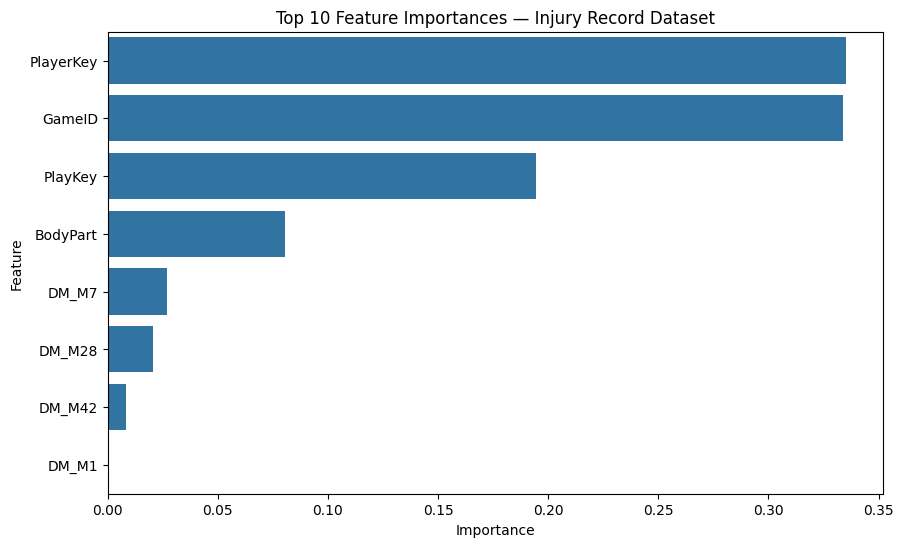

In [18]:
#Video Review Feature Importance Visualization

importances_injury = best_model_injury.feature_importances_
feature_names_injury = X_injury.columns

feat_imp_df_injury = pd.DataFrame({
    'Feature': feature_names_injury,
    'Importance': importances_injury
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df_injury.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances — Injury Record Dataset")
plt.show()


The last dataset, Concussion, contains a list of concussion injuries that occurred in the National Football League from the year 2012 to 2014. The data includes features such as Position, Pre-Season Injury?, Week of Injury, Weeks Injured, Games Missed, Reported Injury Type, Average Playtime Before Injury, etc. The target in this case will be "Reported Injury Type" which will be limited to just concussions.

In [19]:
#Concussion Dataset 

df_concussion = pd.read_csv("Concussion Injuries 2012-2014 (1).csv")
df_clean_concussion = df_concussion.drop(columns=['ID', 'Player', 'Game', 'Date', 'Winning Team?', 'Unknown Injury?'])
df_clean_concussion = df_clean_concussion.dropna()

label_encoder = LabelEncoder()

for col in df_clean_concussion.select_dtypes(include=['object']).columns:
    df_clean_concussion[col] = label_encoder.fit_transform(df_clean_concussion[col].astype(str))

target_column = 'Reported Injury Type'  
X_concussion = df_clean_concussion.drop(columns=[target_column])
y_concussion = df_clean_concussion[target_column]

X_train_concussion, X_test_concussion, y_train_concussion, y_test_concussion = train_test_split(X_concussion, y_concussion, test_size=0.2, random_state=42)

concussion_scaler = StandardScaler()
X_train_scaled_concussion = concussion_scaler.fit_transform(X_train_concussion)

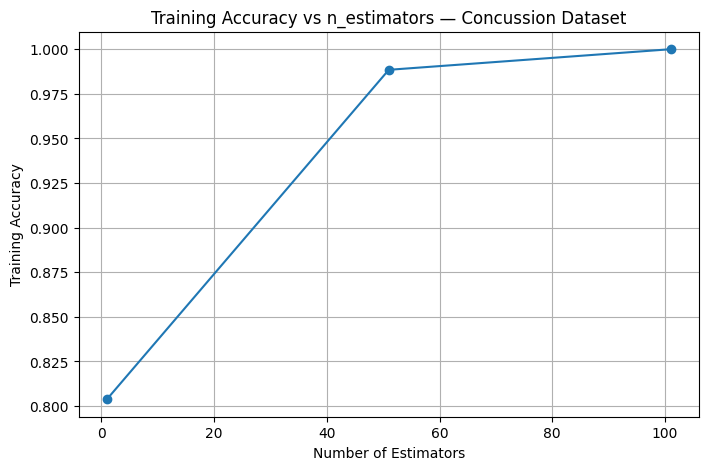

In [20]:
#Concussion Dataset Validation Curve

train_scores_concussion = []
estimators_range_concussion = range(1, 150, 50)

for n in estimators_range_concussion:
    model_concussion = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    model_concussion.fit(X_train_scaled_concussion, y_train_concussion)
    train_scores_concussion.append(accuracy_score(y_train_concussion, model_concussion.predict(X_train_scaled_concussion)))

plt.figure(figsize=(8, 5))
plt.plot(estimators_range_concussion, train_scores_concussion, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs n_estimators — Concussion Dataset")
plt.grid(True)
plt.show()


In [21]:
#Concussion Dataset Hyperparameter Tuning

param_grid_concussion = {
    'n_estimators': [40, 50, 60, 80],
    'learning_rate': [0.01, 0.05],
    'max_depth': [2, 3],
    'subsample': [0.6, 0.8],
    'max_features': ['sqrt', 'log2']
}

grid_search_concussion = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_concussion,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_concussion.fit(X_train_scaled_concussion, y_train_concussion)

print("Best Parameters — Concussion Dataset:", grid_search_concussion.best_params_)
print("Best CV Score — Concussion Dataset:", grid_search_concussion.best_score_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters — Concussion Dataset: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 80, 'subsample': 0.6}
Best CV Score — Concussion Dataset: 0.8884615384615385


In [22]:
#Concussion Dataset Cross Validation

best_model_concussion = grid_search_concussion.best_estimator_

cv_scores_concussion = cross_val_score(
    best_model_concussion,
    X_train_scaled_concussion,
    y_train_concussion,
    cv=5,
    scoring='accuracy'
)

print("Cross-Validation Accuracy Scores — Concussion Dataset:", cv_scores_concussion)
print("Mean CV Accuracy — Concussion Dataset:", np.mean(cv_scores_concussion))


Cross-Validation Accuracy Scores — Concussion Dataset: [0.92307692 0.86538462 0.90384615 0.86538462 0.88461538]
Mean CV Accuracy — Concussion Dataset: 0.8884615384615385


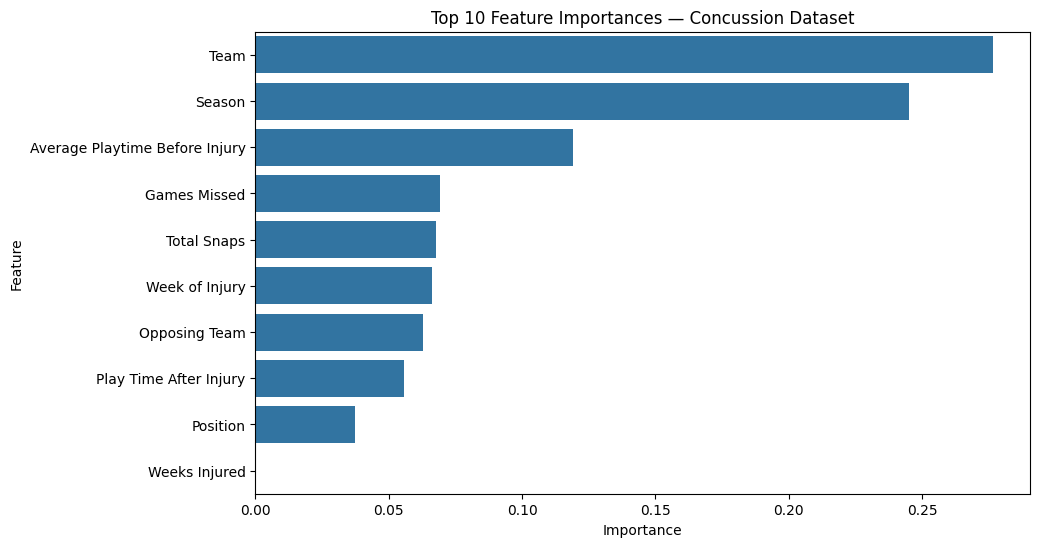

In [23]:
#Concussion Dataset Feature Importance Visualization

importances_concussion = best_model_concussion.feature_importances_
feature_names_concussion = X_concussion.columns

feat_imp_df_concussion = pd.DataFrame({
    'Feature': feature_names_concussion,
    'Importance': importances_concussion
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df_concussion.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances — Concussion Dataset")
plt.show()
